To implement a complete regression problem by performing data preprocessing, model building, evaluation, and result interpretation.
Name:Vaishnavi Sandokar(CS23D0007)

First 5 rows of dataset:
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN       

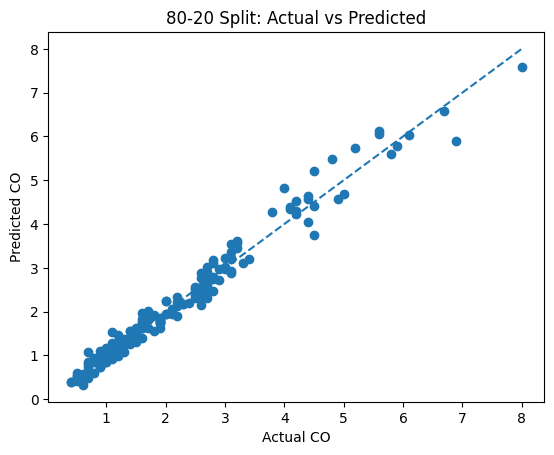


===== 70-30 Split Results =====
MAE: 0.17209573174454726
MSE: 0.052943763957308786
R2 Score: 0.9723210775385667


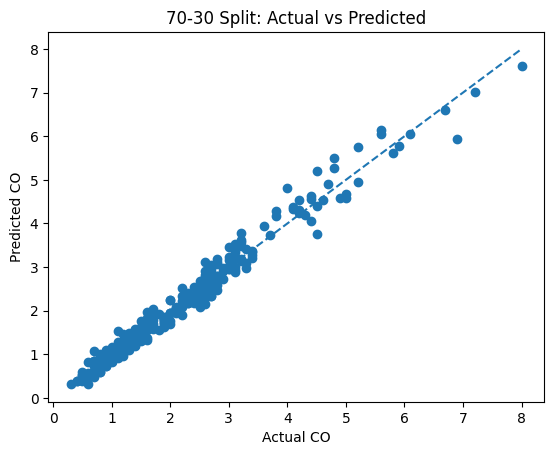

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
data_path = '/content/AirQuality.csv'
data = pd.read_csv(data_path, delimiter=';', decimal=',', header=0, na_values=-200)

# =========================
# DATASET PRINTING
# =========================
print("First 5 rows of dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nDataset Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

# Drop unnecessary columns
data = data.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

# Create Datetime column
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H.%M.%S')

# Drop original columns
data = data.drop(columns=['Date', 'Time'])

# Remove missing values
data.dropna(inplace=True)

# Features and target
X = data.drop(columns=['CO(GT)', 'Datetime'])
y = data['CO(GT)']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 80-20 Split
# =========================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model_80 = LinearRegression()
model_80.fit(X_train_80, y_train_80)

y_pred_80 = model_80.predict(X_test_20)

print("\n===== 80-20 Split Results =====")
print("MAE:", mean_absolute_error(y_test_20, y_pred_80))
print("MSE:", mean_squared_error(y_test_20, y_pred_80))
print("R2 Score:", r2_score(y_test_20, y_pred_80))

# Plot for 80-20
plt.figure()
plt.scatter(y_test_20, y_pred_80)
plt.plot([y_test_20.min(), y_test_20.max()],
         [y_test_20.min(), y_test_20.max()],
         linestyle='--')
plt.xlabel('Actual CO')
plt.ylabel('Predicted CO')
plt.title('80-20 Split: Actual vs Predicted')
plt.show()

# =========================
# 70-30 Split
# =========================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)

y_pred_70 = model_70.predict(X_test_30)

print("\n===== 70-30 Split Results =====")
print("MAE:", mean_absolute_error(y_test_30, y_pred_70))
print("MSE:", mean_squared_error(y_test_30, y_pred_70))
print("R2 Score:", r2_score(y_test_30, y_pred_70))

# Plot for 70-30
plt.figure()
plt.scatter(y_test_30, y_pred_70)
plt.plot([y_test_30.min(), y_test_30.max()],
         [y_test_30.min(), y_test_30.max()],
         linestyle='--')
plt.xlabel('Actual CO')
plt.ylabel('Predicted CO')
plt.title('70-30 Split: Actual vs Predicted')
plt.show()